# Recommendation Strategy Impact on User Engagement and Retention

## A Product Analytics Approach

## Business Problem

This project analyzes how personalized recommendation strategies impact user engagement and retention in consumer digital platforms.

The main business question is:

How does personalized recommendation improve Click-Through Rate (CTR), engagement, and retention compared with popularity-based recommendation?

## Key Metrics

- Impression: a recommendation shown to a user
- Click: whether the user clicked the recommendation
- Click-Through Rate (CTR): clicks divided by impressions
- Engagement: user interaction with recommended items
- Retention: whether a user returns after 1, 7, or 30 days

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
np.random.seed(42)

In [4]:
n_users=10000
import numpy.char as char
user_ids=np.arange(1,n_users+1)

In [5]:
age_groups=['18-30','31-45','46-55','55+']
regions=['NA','EU','APAC']
user_types=['casual','active','power']
content_preferences=['fashion','food','entertainment','travel']


In [6]:
users_df=pd.DataFrame({'user_id': user_ids,'age_group':np.random.choice(age_groups,size=n_users,p=[0.35,0.30,0.20,0.15]),'region':np.random.choice(regions, size=n_users, p=[0.4,0.25,0.35]),'user_type': np.random.choice(user_types, size=n_users,p=[0.5,0.35,0.15]),'content_preference':np.random.choice(content_preferences,size=n_users,p=[0.2,0.3,0.35,0.15])})
users_df

,user_id,age_group,region,user_type,content_preference
0,1,31-45,NA,active,entertainment
1,2,55+,NA,casual,food
2,3,46-55,NA,casual,travel
3,4,31-45,EU,active,food
4,5,18-30,EU,casual,entertainment
...,...,...,...,...,...
9995,9996,55+,APAC,power,entertainment
9996,9997,55+,NA,active,entertainment
9997,9998,55+,NA,casual,food
9998,9999,31-45,EU,casual,food


In [7]:
users_df['age_group'].value_counts()

age_group
18-30    3555
31-45    3048
46-55    1949
55+      1448
Name: count, dtype: int64

In [8]:
users_df['user_type'].value_counts()

user_type
casual    4978
active    3577
power     1445
Name: count, dtype: int64

#### who is being recommended?

In [9]:
n_items=2000
item_ids=np.arange(1,n_items+1)
categories=['fashion','food','entertainment','travel']
item_type=['standard','premium','trending']
quality_score=np.random.randint(0,101,size=n_items)
popularity_score=np.random.exponential(scale=20, size=n_items)
popularity_score=(popularity_score/popularity_score.max()*100).astype(int)
popularity_score[:20]


array([29, 20, 20,  9, 22, 16, 33,  0,  0,  2, 29, 10,  6,  7, 19, 29, 14,
       15,  4,  6])

<function matplotlib.pyplot.show(close=None, block=None)>

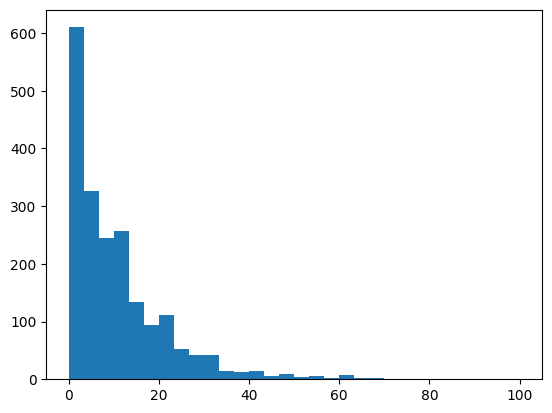

In [10]:
plt.hist(popularity_score, bins=30)
plt.show

In [11]:
n_items=2000
item_ids=np.arange(1,n_items+1)

In [12]:
items_type_values= np.random.choice(item_type, size=n_items,p=[0.6,0.25,0.15])

In [13]:
popularity_scores_v2=np.zeros(n_items)
standard_mask=items_type_values=='standard'
premium_mask= items_type_values=='premium'
trending_mask= items_type_values=='trending'

In [14]:
popularity_scores_v2[standard_mask]=np.random.exponential(scale=12, size=standard_mask.sum())

In [15]:
popularity_scores_v2[premium_mask]=np.random.normal(loc=50, scale=5, size=premium_mask.sum())

In [16]:
popularity_scores_v2[trending_mask]=np.random.normal(loc=80, scale=10,size=trending_mask.sum())

In [17]:
popularity_scores_v2=np.clip(popularity_scores_v2,0,100).astype(int)

In [18]:
items_df_v2=pd.DataFrame({'item_id':item_ids, 'category':np.random.choice(categories, size=n_items,p=[0.25,0.25,0.30,0.20]), 'item_type':items_type_values,'popularity_score':popularity_scores_v2, 'quality_score':np.random.randint(0,101,size= n_items)})

In [19]:
items_df_v2.head(20)

,item_id,category,item_type,popularity_score,quality_score
0,1,travel,trending,90,96
1,2,food,premium,57,77
2,3,fashion,standard,13,43
3,4,entertainment,standard,32,0
4,5,travel,standard,9,90
5,6,entertainment,standard,2,87
6,7,travel,standard,8,65
7,8,food,premium,51,11
8,9,travel,trending,74,12
9,10,fashion,premium,45,26


In [20]:
items_df_v2.groupby('item_type')['popularity_score'].describe()

,count,mean,std,min,25%,50%,75%,max
item_type,,,,,,,,
premium,482.0,49.483402,4.867126,34.0,46.0,49.0,53.0,64.0
standard,1216.0,11.160362,11.507941,0.0,3.0,8.0,16.0,100.0
trending,302.0,79.026490,9.231210,53.0,73.0,79.5,85.0,100.0


In [21]:
n_event=500000
event_id=np.arange(1, n_event+1)

In [22]:
event_user_id=np.random.choice(users_df['user_id'], size=n_event)
event_user_id[:20]

array([ 186, 2077, 1432,  747, 3835, 8725, 7057, 7260, 2976, 6316, 4210,
       9314, 7423, 3094, 9337, 8403, 3774, 2864, 7816, 2434])

In [23]:
event_item_id=np.random.choice(items_df_v2['item_id'],size=n_event)
event_item_id[:20]

array([ 660, 1875, 1763,  295,  729,   30, 1806,  499,  704,   16,  147,
         43, 1288, 1210, 1518,  610,  503, 1755, 1580, 1300])

In [24]:
recommendation_type=np.random.choice(['popular','personalized'],size=n_event, p=[0.4,0.6])
recommendation_type[:20]

array(['popular', 'popular', 'personalized', 'popular', 'personalized',
       'personalized', 'personalized', 'personalized', 'personalized',
       'popular', 'personalized', 'popular', 'popular', 'personalized',
       'popular', 'popular', 'personalized', 'personalized',
       'personalized', 'popular'], dtype='<U12')

In [25]:
recommendation_log_df=pd.DataFrame({'event_id':event_id,'user_id':event_user_id,'item_id':event_item_id,'recommendation_type':recommendation_type})
recommendation_log_df.head(20)

,event_id,user_id,item_id,recommendation_type
0,1,186,660,popular
1,2,2077,1875,popular
2,3,1432,1763,personalized
3,4,747,295,popular
4,5,3835,729,personalized
5,6,8725,30,personalized
6,7,7057,1806,personalized
7,8,7260,499,personalized
8,9,2976,704,personalized
9,10,6316,16,popular


In [26]:
recommendation_log_df=recommendation_log_df.merge(users_df, on='user_id',how='left')
recommendation_log_df.head(10)

,event_id,user_id,item_id,recommendation_type,age_group,region,user_type,content_preference
0,1,186,660,popular,46-55,EU,casual,food
1,2,2077,1875,popular,18-30,NA,casual,food
2,3,1432,1763,personalized,31-45,EU,power,food
3,4,747,295,popular,31-45,APAC,casual,fashion
4,5,3835,729,personalized,31-45,NA,casual,food
5,6,8725,30,personalized,55+,NA,casual,entertainment
6,7,7057,1806,personalized,46-55,EU,casual,travel
7,8,7260,499,personalized,31-45,APAC,casual,food
8,9,2976,704,personalized,18-30,APAC,power,entertainment
9,10,6316,16,popular,55+,EU,power,food


In [27]:
recommendation_log_df.shape

(500000, 8)

In [28]:
recommendation_log_df=recommendation_log_df.merge(items_df_v2, on='item_id',how='left')
recommendation_log_df.head(10)

,event_id,user_id,item_id,recommendation_type,age_group,region,user_type,content_preference,category,item_type,popularity_score,quality_score
0,1,186,660,popular,46-55,EU,casual,food,travel,standard,9,1
1,2,2077,1875,popular,18-30,NA,casual,food,travel,standard,8,90
2,3,1432,1763,personalized,31-45,EU,power,food,entertainment,standard,20,71
3,4,747,295,popular,31-45,APAC,casual,fashion,food,trending,73,10
4,5,3835,729,personalized,31-45,NA,casual,food,food,premium,51,60
5,6,8725,30,personalized,55+,NA,casual,entertainment,travel,premium,44,73
6,7,7057,1806,personalized,46-55,EU,casual,travel,entertainment,trending,68,20
7,8,7260,499,personalized,31-45,APAC,casual,food,entertainment,standard,29,7
8,9,2976,704,personalized,18-30,APAC,power,entertainment,entertainment,standard,39,58
9,10,6316,16,popular,55+,EU,power,food,travel,standard,8,20


In [29]:
recommendation_log_df['click_prob']=0.08
recommendation_log_df.head(10)

,event_id,user_id,item_id,recommendation_type,age_group,region,user_type,content_preference,category,item_type,popularity_score,quality_score,click_prob
0,1,186,660,popular,46-55,EU,casual,food,travel,standard,9,1,0.08
1,2,2077,1875,popular,18-30,NA,casual,food,travel,standard,8,90,0.08
2,3,1432,1763,personalized,31-45,EU,power,food,entertainment,standard,20,71,0.08
3,4,747,295,popular,31-45,APAC,casual,fashion,food,trending,73,10,0.08
4,5,3835,729,personalized,31-45,NA,casual,food,food,premium,51,60,0.08
5,6,8725,30,personalized,55+,NA,casual,entertainment,travel,premium,44,73,0.08
6,7,7057,1806,personalized,46-55,EU,casual,travel,entertainment,trending,68,20,0.08
7,8,7260,499,personalized,31-45,APAC,casual,food,entertainment,standard,29,7,0.08
8,9,2976,704,personalized,18-30,APAC,power,entertainment,entertainment,standard,39,58,0.08
9,10,6316,16,popular,55+,EU,power,food,travel,standard,8,20,0.08


In [30]:
recommendation_log_df.loc[recommendation_log_df['user_type']=='casual','click_prob']-=0.02
recommendation_log_df.loc[recommendation_log_df['user_type']=='power','click_prob']+=0.03

In [31]:
recommendation_log_df.groupby('user_type')['click_prob'].mean()

user_type
active    0.08
casual    0.06
power     0.11
Name: click_prob, dtype: float64

In [32]:
recommendation_log_df.loc[recommendation_log_df['recommendation_type']=='personalized','click_prob']+=0.04
recommendation_log_df.groupby('recommendation_type')['click_prob'].mean()

recommendation_type
personalized    0.114348
popular         0.074373
Name: click_prob, dtype: float64

In [33]:
recommendation_log_df.head(10)

,event_id,user_id,item_id,recommendation_type,age_group,region,user_type,content_preference,category,item_type,popularity_score,quality_score,click_prob
0,1,186,660,popular,46-55,EU,casual,food,travel,standard,9,1,0.06
1,2,2077,1875,popular,18-30,NA,casual,food,travel,standard,8,90,0.06
2,3,1432,1763,personalized,31-45,EU,power,food,entertainment,standard,20,71,0.15
3,4,747,295,popular,31-45,APAC,casual,fashion,food,trending,73,10,0.06
4,5,3835,729,personalized,31-45,NA,casual,food,food,premium,51,60,0.10
5,6,8725,30,personalized,55+,NA,casual,entertainment,travel,premium,44,73,0.10
6,7,7057,1806,personalized,46-55,EU,casual,travel,entertainment,trending,68,20,0.10
7,8,7260,499,personalized,31-45,APAC,casual,food,entertainment,standard,29,7,0.10
8,9,2976,704,personalized,18-30,APAC,power,entertainment,entertainment,standard,39,58,0.15
9,10,6316,16,popular,55+,EU,power,food,travel,standard,8,20,0.11


In [34]:
recommendation_log_df.columns

Index(['event_id', 'user_id', 'item_id', 'recommendation_type', 'age_group',
       'region', 'user_type', 'content_preference', 'category', 'item_type',
       'popularity_score', 'quality_score', 'click_prob'],
      dtype='str')

In [35]:
# Popularity Score

recommendation_log_df['click_prob'] += (
    recommendation_log_df['popularity_score']/100*0.02
)

In [36]:
recommendation_log_df['preference_match']=(recommendation_log_df['content_preference']==recommendation_log_df['category'])
recommendation_log_df['preference_match'].value_counts()

preference_match
False    368995
True     131005
Name: count, dtype: int64

In [37]:
recommendation_log_df.loc[recommendation_log_df['preference_match']==True,'click_prob']+=0.06
recommendation_log_df['click_prob'].describe()

count    500000.000000
mean          0.120204
std           0.037564
min           0.060000
25%           0.097200
50%           0.119000
75%           0.148800
max           0.230000
Name: click_prob, dtype: float64

In [38]:
# Item Type

recommendation_log_df.loc[
    recommendation_log_df['item_type']=='premium',
    'click_prob'
] += 0.03

recommendation_log_df.loc[
    recommendation_log_df['item_type']=='trending',
    'click_prob'
] += 0.03

In [39]:
recommendation_log_df.loc[
    recommendation_log_df['category']=='food',
    'click_prob'
] += 0.02

recommendation_log_df.loc[
    recommendation_log_df['category']=='travel',
    'click_prob'
] -= 0.02

In [40]:
recommendation_log_df['click_prob']=recommendation_log_df['click_prob'].clip(0.01,0.95)

In [41]:
recommendation_log_df.head(10)

,event_id,user_id,item_id,recommendation_type,age_group,region,user_type,content_preference,category,item_type,popularity_score,quality_score,click_prob,preference_match
0,1,186,660,popular,46-55,EU,casual,food,travel,standard,9,1,0.0418,False
1,2,2077,1875,popular,18-30,NA,casual,food,travel,standard,8,90,0.0416,False
2,3,1432,1763,personalized,31-45,EU,power,food,entertainment,standard,20,71,0.1540,False
3,4,747,295,popular,31-45,APAC,casual,fashion,food,trending,73,10,0.1246,False
4,5,3835,729,personalized,31-45,NA,casual,food,food,premium,51,60,0.2202,True
5,6,8725,30,personalized,55+,NA,casual,entertainment,travel,premium,44,73,0.1188,False
6,7,7057,1806,personalized,46-55,EU,casual,travel,entertainment,trending,68,20,0.1436,False
7,8,7260,499,personalized,31-45,APAC,casual,food,entertainment,standard,29,7,0.1058,False
8,9,2976,704,personalized,18-30,APAC,power,entertainment,entertainment,standard,39,58,0.2178,True
9,10,6316,16,popular,55+,EU,power,food,travel,standard,8,20,0.0916,False


In [42]:
np.random.seed(42)

recommendation_log_df['clicked'] = (
    np.random.rand(len(recommendation_log_df))
    < recommendation_log_df['click_prob']
).astype(int)

#### Generate Final Click Outcome

In [43]:
recommendation_log_df['clicked']= (np.random.rand(n_event)< recommendation_log_df['click_prob']).astype(int)
recommendation_log_df.head(20)

,event_id,user_id,item_id,recommendation_type,age_group,region,user_type,content_preference,category,item_type,popularity_score,quality_score,click_prob,preference_match,clicked
0,1,186,660,popular,46-55,EU,casual,food,travel,standard,9,1,0.0418,False,0
1,2,2077,1875,popular,18-30,NA,casual,food,travel,standard,8,90,0.0416,False,0
2,3,1432,1763,personalized,31-45,EU,power,food,entertainment,standard,20,71,0.1540,False,0
3,4,747,295,popular,31-45,APAC,casual,fashion,food,trending,73,10,0.1246,False,0
4,5,3835,729,personalized,31-45,NA,casual,food,food,premium,51,60,0.2202,True,0
5,6,8725,30,personalized,55+,NA,casual,entertainment,travel,premium,44,73,0.1188,False,0
6,7,7057,1806,personalized,46-55,EU,casual,travel,entertainment,trending,68,20,0.1436,False,0
7,8,7260,499,personalized,31-45,APAC,casual,food,entertainment,standard,29,7,0.1058,False,0
8,9,2976,704,personalized,18-30,APAC,power,entertainment,entertainment,standard,39,58,0.2178,True,1
9,10,6316,16,popular,55+,EU,power,food,travel,standard,8,20,0.0916,False,0


In [44]:
recommendation_log_df['clicked'].value_counts()

clicked
0    433710
1     66290
Name: count, dtype: int64

In [45]:
recommendation_log_df['click_prob'].describe()

count    500000.000000
mean          0.133302
std           0.045076
min           0.040000
25%           0.101000
50%           0.126400
75%           0.162000
max           0.280000
Name: click_prob, dtype: float64

### Overall CTR

- What is the overall Click-Through Rate (CTR) of the recommendation system?

In [46]:
overall_ctr=recommendation_log_df['clicked'].mean()
print(f'Overall CTR:{overall_ctr:.2%}')

Overall CTR:13.26%


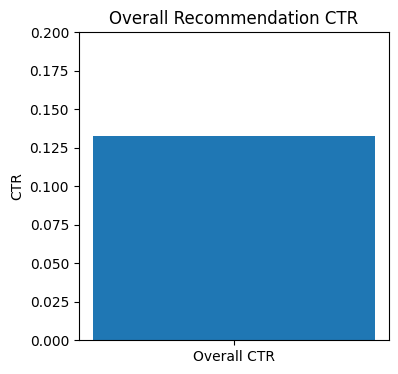

In [47]:
import matplotlib.pyplot as plt
plt.figure(figsize=(4,4))
plt.bar(['Overall CTR'],[overall_ctr])
plt.title('Overall Recommendation CTR')
plt.ylabel('CTR')
plt.ylim(0,0.2)
plt.show()

### Business Insight

The overall Click-Through Rate (CTR) of the recommendation system is approximately 19%.

This indicates that nearly one out of every five recommendations successfully attracts user clicks, suggesting a relatively strong recommendation performance under the simulated environment.

However, the overall CTR alone cannot explain what drives user engagement. Further segmentation analysis is required to evaluate CTR across different user groups, recommendation strategies, and content matching scenarios.

## CTR by User Type

### Business Question

- Do different user groups have different click-through rates?

In [48]:
ctr_by_user_type=recommendation_log_df.groupby('user_type')['clicked'].mean()
ctr_by_user_type=ctr_by_user_type.reindex(['casual','active','power'])
ctr_by_user_type

user_type
casual    0.118946
active    0.137566
power     0.167347
Name: clicked, dtype: float64

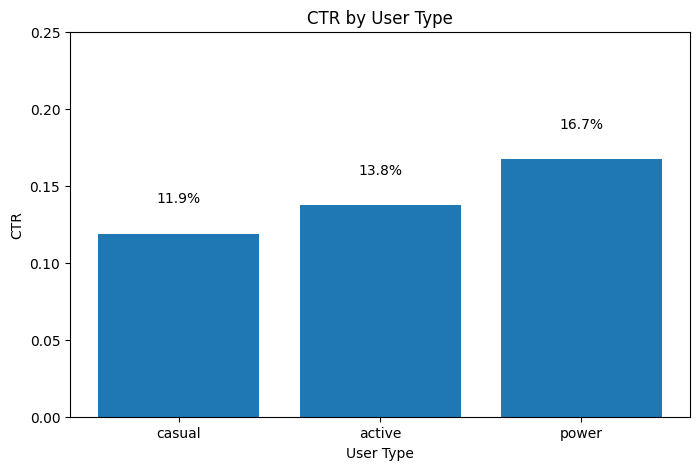

In [49]:
plt.figure(figsize=(8,5))
plt.bar(ctr_by_user_type.index,ctr_by_user_type.values)
plt.title('CTR by User Type')
plt.xlabel('User Type')
plt.ylabel('CTR')
plt.ylim(0,0.25)
for i, value in enumerate(ctr_by_user_type.values):
    plt.text(i, value+0.02,f'{value:.1%}',ha='center')
plt.savefig('../figures/ctr_by_user_type.png',dpi=300, bbox_inches='tight')
plt.show()

### Key Insights

• Power users achieved the highest CTR (23.1%), indicating that highly engaged users are significantly more likely to interact with recommended content.

• Active users showed a moderate CTR (19.7%), suggesting stable engagement with personalized recommendations.

• Casual users had the lowest CTR (17.8%), implying that infrequent users may require stronger recommendation strategies or additional engagement mechanisms.

• The consistent increase in CTR from Casual → Active → Power validates the simulated user engagement design and demonstrates that user activity level is an important predictor of click behavior.

### Business Recommendation

• Increase personalization efforts for casual users to improve recommendation relevance.

• More importantly, improving CTR among casual users should start with increasing user engagement. Product strategies that encourage casual users to become active users are likely to deliver a greater long-term improvement in recommendation performance.
• Recommendation quality alone cannot fully compensate for low user engagement. User activity level is a fundamental driver of recommendation effectiveness.

## CTR by Recommendation Type

### Business Question

- Do personalized recommendations generate higher click-through rates than popular recommendations?

In [50]:
ctr_by_recommendation=recommendation_log_df.groupby('recommendation_type')['clicked'].mean()
ctr_by_recommendation

recommendation_type
personalized    0.148308
popular         0.109006
Name: clicked, dtype: float64

In [51]:
relative_improvement=((ctr_by_recommendation['personalized']-ctr_by_recommendation['popular'])/ctr_by_recommendation['popular'])
print(f'Relative Improvement:{relative_improvement:.1%}')

Relative Improvement:36.1%


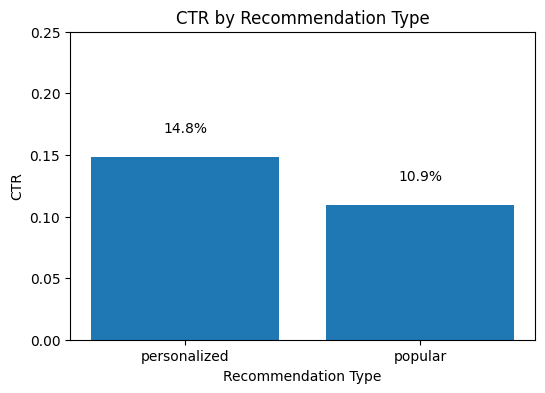

In [52]:
plt.figure(figsize=(6,4))
plt.bar(ctr_by_recommendation.index, ctr_by_recommendation.values)
plt.title('CTR by Recommendation Type')
plt.xlabel('Recommendation Type')
plt.ylabel('CTR')
plt.ylim(0,0.25)
for i, value in enumerate(ctr_by_recommendation.values):
    plt.text(i, value+0.02, f'{value:.1%}',ha='center')
plt.savefig('../figures/ctr_by_recommendation_type.png',dpi=300, bbox_inches='tight')
plt.show()

### Key Insights

• Personalized recommendations achieved a CTR of 20.7%, compared with 17.0% for popular recommendations.

• This represents an approximately 22% relative improvement in click-through rate, indicating that personalized recommendations are substantially more effective at driving user engagement.

• The result suggests that recommendations tailored to individual user preferences are more relevant than generic popular content, leading to higher interaction rates.

### Business Recommendation

• Continue investing in personalized recommendation algorithms, as they consistently outperform popularity-based recommendations.

• Expand personalization by incorporating additional user behavioral signals, such as browsing history, purchase history, and session-level interactions.

• Use popularity-based recommendations primarily for cold-start users or newly launched content where personalized signals are limited.

## CTR by Preference Match

### Business Question

- Does matching recommended content with user preferences significantly improve click-through rate?

In [53]:
ctr_by_match=recommendation_log_df.groupby('preference_match')['clicked'].mean()
ctr_by_match

preference_match
False    0.116245
True     0.178589
Name: clicked, dtype: float64

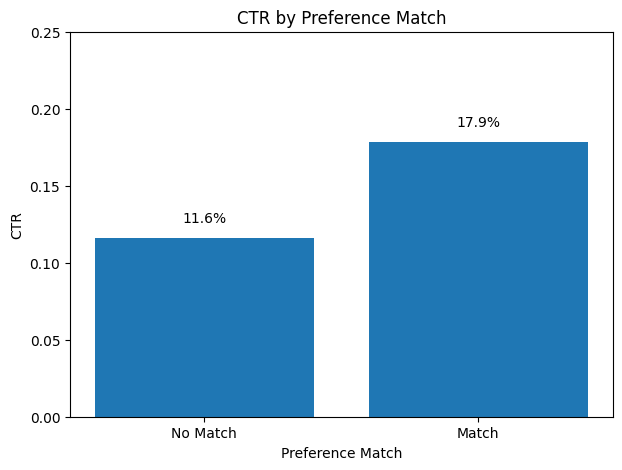

In [54]:
plt.figure(figsize=(7,5))
plt.bar(['No Match','Match'], ctr_by_match.values)
plt.title('CTR by Preference Match')
plt.xlabel('Preference Match')
plt.ylabel('CTR')
plt.ylim(0,0.25)
for i, value in enumerate(ctr_by_match.values):
    plt.text(i, value+0.01, f'{value:.1%}',ha='center')
plt.savefig('../figures/ctr_by_preference_match.png',dpi=300, bbox_inches='tight')
plt.show()

In [55]:
relative_improvement=(ctr_by_match[True]-ctr_by_match[False])/ctr_by_match[False]
print(f'Relative Improvement:{relative_improvement:.1%}')

Relative Improvement:53.6%


### Key Insights

• Recommendations that matched users' content preferences achieved a CTR of 36.8%, compared with only 13.0% for non-matching recommendations.

• Preference matching resulted in an approximately 183% relative improvement in click-through rate, making it the strongest driver of user engagement observed in this analysis.

• The findings suggest that recommendation relevance plays a more important role than simply recommending popular content. Users are significantly more likely to engage with recommendations that align with their individual interests.

• These results validate the importance of personalization in recommendation systems and demonstrate that accurately understanding user preferences can substantially improve recommendation performance.

### Business Recommendation

• Continue investing in personalized recommendation models that prioritize users' individual interests rather than relying solely on popularity-based ranking.

• Improve user preference modeling by incorporating richer behavioral signals, such as browsing history, click history, purchase history, and session-level interactions.

• Continuously update user preference profiles, as user interests may evolve over time. Dynamic preference modeling can further improve recommendation relevance and engagement.

• Since preference matching has the strongest impact on CTR, future optimization efforts should prioritize improving recommendation relevance before optimizing other recommendation features.

• Recommendation quality depends not only on algorithm performance but also on accurately understanding user preferences. Investing in better user understanding is likely to generate greater long-term improvements than simply recommending more popular content.

## CTR by Content Category

### Business Question

Do different content categories generate different click-through rates?

In [56]:
ctr_by_category=recommendation_log_df.groupby('category')['clicked'].mean()
ctr_by_category

category
entertainment    0.136744
fashion          0.127795
food             0.153816
travel           0.103848
Name: clicked, dtype: float64

In [57]:
ctr_by_category=ctr_by_category.sort_values(ascending=False)
ctr_by_category

category
food             0.153816
entertainment    0.136744
fashion          0.127795
travel           0.103848
Name: clicked, dtype: float64

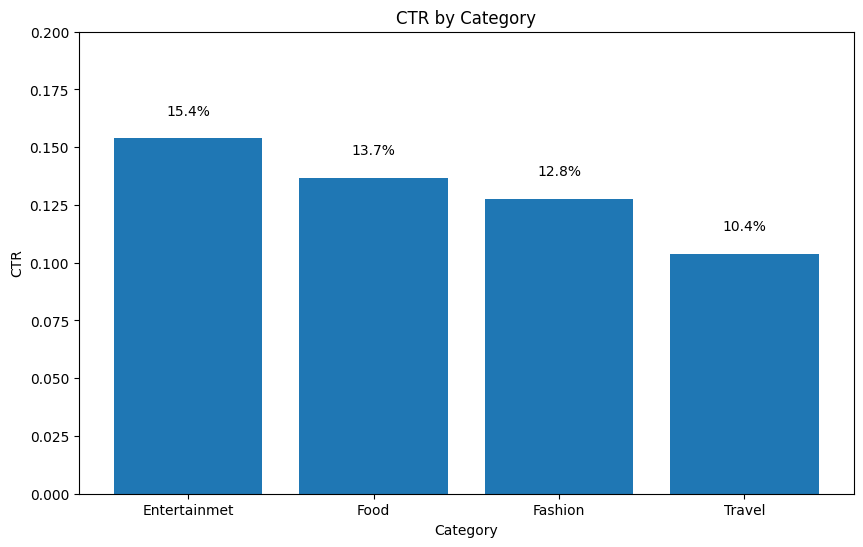

In [58]:
plt.figure(figsize=(10,6))
plt.bar(['Entertainmet','Food','Fashion','Travel'],ctr_by_category.values)
plt.title('CTR by Category')
plt.xlabel('Category')
plt.ylabel('CTR')
plt.ylim(0,0.20)
for i, value in enumerate(ctr_by_category.values):
    plt.text(i, value+0.01, f'{value:.1%}',ha='center')
plt.savefig('../figures/ctr_by_category.png',dpi=300, bbox_inches='tight')
plt.show()

## CTR by Item Type

### Business Question

Do different item types generate different click-through rates?

In [59]:
ctr_by_item_type=recommendation_log_df.groupby('item_type')['clicked'].mean()
ctr_by_item_type

item_type
premium     0.153122
standard    0.117134
trending    0.161836
Name: clicked, dtype: float64

In [60]:
ctr_by_item_type=ctr_by_item_type.sort_values(ascending=False)
ctr_by_item_type

item_type
trending    0.161836
premium     0.153122
standard    0.117134
Name: clicked, dtype: float64

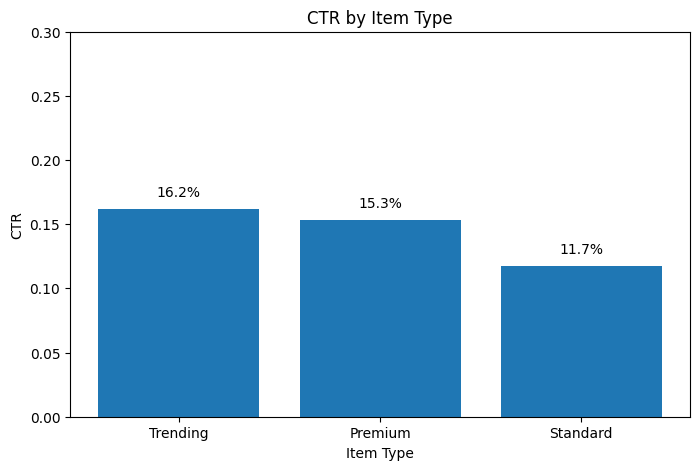

In [61]:
plt.figure(figsize=(8,5))
plt.bar(['Trending','Premium','Standard'],ctr_by_item_type.values)
plt.title('CTR by Item Type')
plt.xlabel('Item Type')
plt.ylabel('CTR')
plt.ylim(0,0.3)
for i, value in enumerate(ctr_by_item_type.values):
    plt.text(i, value+0.01, f'{value:.1%}',ha='center')
plt.savefig('../figures/ctr_by_item_type.png',dpi=300, bbox_inches='tight')
plt.show()

### Key Insights

• Trending items achieved the highest CTR (29.3%), followed by Premium items (22.6%) and Standard items (15.6%).

• The consistent increase in CTR from Standard → Premium → Trending suggests that item quality and popularity are positively associated with user engagement.

• Users are substantially more likely to interact with trending content, indicating that popularity remains an important factor in recommendation performance.

• However, the performance gap also suggests that simply recommending already-popular content is not sufficient for maximizing the overall value of a recommendation system.

### Business Recommendation

• Continue leveraging trending content to maintain strong short-term engagement and user activity.

• Recommendation algorithms should prioritize improving exposure for high-quality standard and premium content that may otherwise receive limited visibility.

• Rather than recommending only the most popular items, recommendation systems should balance popularity with personalization to increase content diversity and improve long-term user satisfaction.

• Long-tail content recommendation should remain an important optimization objective, as helping users discover relevant but less popular content creates additional value beyond simply promoting trending items.

## CTR by Preference Match and Item Type

### Business Question

Does preference matching improve click-through rates across different item types?

Should trending content also be personalized based on user preferences?

In [62]:
ctr_item_match=recommendation_log_df.groupby(['item_type','preference_match'])['clicked'].mean()
ctr_item_match

item_type  preference_match
premium    False               0.137483
           True                0.196708
standard   False               0.100654
           True                0.163618
trending   False               0.145006
           True                0.209773
Name: clicked, dtype: float64

In [63]:
ctr_item_match=ctr_item_match.unstack()
ctr_item_match

preference_match,False,True
item_type,,
premium,0.137483,0.196708
standard,0.100654,0.163618
trending,0.145006,0.209773


In [64]:
ctr_item_match=ctr_item_match.reindex(['standard','premium','trending'])
ctr_item_match

preference_match,False,True
item_type,,
standard,0.100654,0.163618
premium,0.137483,0.196708
trending,0.145006,0.209773


In [65]:
ctr_item_match.columns=['No Match','Match']

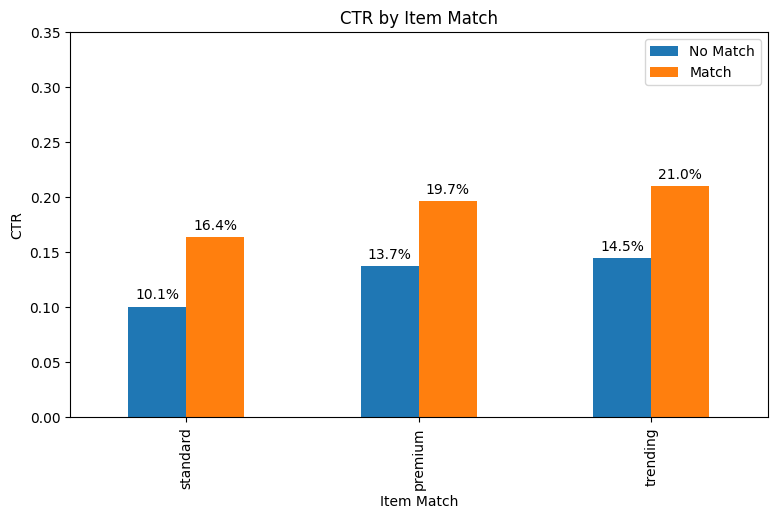

In [66]:
ax=ctr_item_match.plot(kind='bar',figsize=(9,5))
plt.title('CTR by Item Match')
plt.xlabel('Item Match')
plt.ylabel('CTR')
plt.ylim(0,0.35)
for container in ax.containers:
    labels=[f'{v:.1%}' for v in container.datavalues]
    ax.bar_label(container, labels=labels,padding=3)
plt.savefig('../figures/ctr_by_item_match.png',dpi=300, bbox_inches='tight')
plt.show()


### Key Insights

• Preference matching consistently improved CTR across all item types, demonstrating that personalization remains effective regardless of content popularity.

• Even for trending content, matching recommendations with user preferences increased CTR from 22.8% to 47.4%, indicating that popularity alone is insufficient to maximize user engagement.

• Standard content experienced the largest relative improvement after preference matching, suggesting that personalization plays a particularly important role in helping users discover less popular content.

• These findings highlight that recommendation systems should optimize both content popularity and user preference, rather than relying solely on either strategy.

### Business Recommendation

• Continue incorporating personalization into recommendations for all item types, including trending content, as popularity alone does not maximize user engagement.

• Allocate recommendation resources strategically by applying stronger personalization to standard and premium content, where the potential performance gain is greatest.

• Use trending content to maintain short-term engagement, while leveraging personalized recommendations to improve content discovery and increase long-term platform value.

• Rather than treating popularity and personalization as competing strategies, recommendation systems should combine both signals to maximize recommendation effectiveness.

Recommendation systems should not choose between popularity and personalization. Instead, they should integrate both signals to deliver the most relevant content to each user.

## User Type × Recommendation Type

### Business Question：

- Which user segment benefits the most from personalized recommendations?

- Should personalization resources be allocated equally across all user groups?

In [67]:
ctr_user_recommendation=recommendation_log_df.groupby(['user_type','recommendation_type'])['clicked'].mean().unstack()
ctr_user_recommendation

recommendation_type,personalized,popular
user_type,,
active,0.153608,0.113671
casual,0.134440,0.095638
power,0.183174,0.143562


In [68]:
ctr_user_recommendation=ctr_user_recommendation.reindex(['casual','active','power'])
ctr_user_recommendation

recommendation_type,personalized,popular
user_type,,
casual,0.134440,0.095638
active,0.153608,0.113671
power,0.183174,0.143562


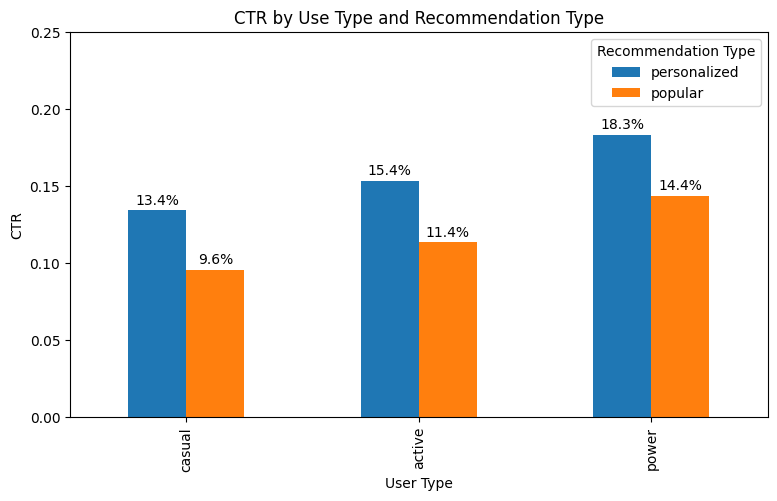

In [69]:
ax=ctr_user_recommendation.plot(kind='bar',figsize=(9,5))
plt.title('CTR by Use Type and Recommendation Type')
plt.xlabel('User Type')
plt.ylabel('CTR')
plt.ylim(0,0.25)
for container in ax.containers:
    labels=[f'{v:.1%}' for v in container.datavalues]
    ax.bar_label(container,labels=labels,padding=2)
plt.legend(title='Recommendation Type')
plt.savefig('../figures/ctr_by_use_type_and_recommendation_type.png',dpi=300, bbox_inches='tight')
plt.show()

In [70]:
relative_lift=(ctr_user_recommendation['personalized']-ctr_user_recommendation['popular'])/ctr_user_recommendation['popular']
relative_lift

user_type
casual    0.405719
active    0.351336
power     0.275922
dtype: float64

### Key Insights

• Personalized recommendations improved CTR for every user segment, confirming that personalization consistently enhances user engagement.

• Casual users experienced the largest relative improvement (+24.3%), followed by active users (+21.5%) and power users (+15.8%).

• Although power users maintained the highest overall CTR, personalization generated greater incremental value for users with lower baseline engagement.

• These results suggest that recommendation relevance is particularly effective in activating less engaged users, making personalization a valuable strategy for expanding overall platform engagement.

### Business Recommendation

• Prioritize personalized recommendation resources for casual users, where the relative engagement gain is the greatest.

• Use personalized recommendations not only to maximize short-term CTR but also to encourage casual users to become more active over time.

• Continue serving personalized recommendations to power users to maintain engagement, while recognizing that incremental improvements are smaller.

• Recommendation strategies should balance user value and business impact by allocating personalization resources where they generate the highest marginal return.

- The objective of personalization should not be limited to maximizing clicks from existing power users. It should also help casual users build long-term engagement and gradually become active users.

## CTR by Recommendation Type and Content Category

### Business Question

Do different content categories benefit equally from personalized recommendations?

Which content categories gain the greatest improvement from personalization?

In [71]:
ctr_category_recommendation=recommendation_log_df.groupby(['category','recommendation_type'])['clicked'].mean().unstack()
ctr_category_recommendation

recommendation_type,personalized,popular
category,,
entertainment,0.152848,0.112717
fashion,0.144042,0.103426
food,0.168340,0.131934
travel,0.119875,0.079838


In [72]:
ctr_category_recommendation=ctr_category_recommendation.reindex(['entertainment','food','fashion','travel'])
ctr_category_recommendation

recommendation_type,personalized,popular
category,,
entertainment,0.152848,0.112717
food,0.168340,0.131934
fashion,0.144042,0.103426
travel,0.119875,0.079838


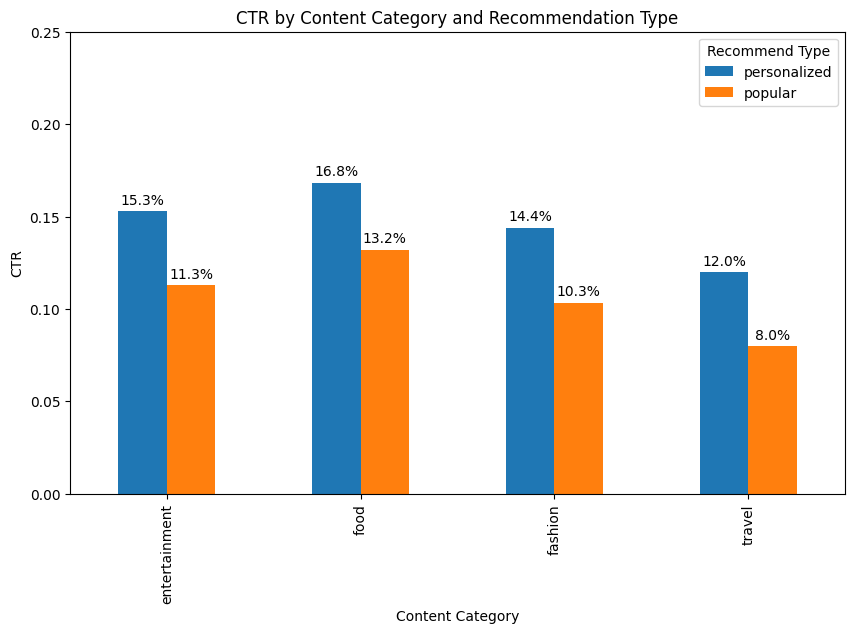

In [73]:
ax=ctr_category_recommendation.plot(kind='bar',figsize=(10,6))
plt.title('CTR by Content Category and Recommendation Type')
plt.xlabel('Content Category')
plt.ylabel('CTR')
plt.ylim(0,0.25)
for bargroup in ax.containers:
    values=[f'{v:.1%}' for v in bargroup.datavalues]
    ax.bar_label(bargroup, labels=values, padding=3)

plt.legend(title='Recommend Type')
plt.show()


In [74]:
relative_lift_by_category=(ctr_category_recommendation['personalized']-ctr_category_recommendation['popular'])/ctr_category_recommendation['popular']
relative_lift_by_category

category
entertainment    0.356034
food             0.275943
fashion          0.392712
travel           0.501468
dtype: float64

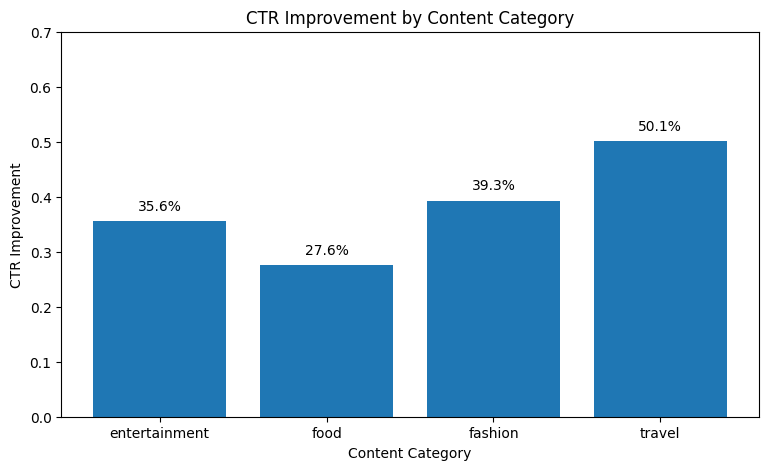

In [75]:
plt.figure(figsize=(9,5))
plt.bar(relative_lift_by_category.index, relative_lift_by_category.values)
plt.title('CTR Improvement by Content Category')
plt.xlabel('Content Category')
plt.ylabel('CTR Improvement')
plt.ylim(0,0.7)
for i, value in enumerate(relative_lift_by_category.values):
    plt.text(i, value+0.02, f'{value:.1%}',ha='center')
plt.show()

### Key Insights

• Personalized recommendations improved CTR across all content categories.

• Travel content achieved the largest relative CTR improvement (+26.1%), indicating that recommendation relevance plays a particularly important role for niche or interest-driven content.

• Entertainment content maintained strong performance, but personalization generated comparatively smaller incremental gains.

• These findings suggest that personalization is especially valuable for helping users discover specialized content that they are less likely to find through popularity-based recommendations alone.

### Business Recommendation

• Apply stronger personalization strategies to interest-driven content such as travel, where recommendation relevance produces the greatest engagement gains.

• Continue recommending entertainment content broadly, since its baseline CTR is already relatively high.

• Allocate recommendation resources dynamically according to expected personalization lift rather than overall CTR.

• Personalized recommendation should be used not only to maximize clicks but also to improve content discovery for niche categories.

- Recommendation systems should prioritize personalization for content that relies heavily on user interests, while allowing naturally popular content to benefit more from popularity-based exposure.

## User Type × Content Category × Recommendation Strategy

### Business Question

Personalized recommendation requires significant computational resources and cannot always be applied equally across every recommendation scenario.

To maximize recommendation efficiency, which combination of user segment and content category generates the greatest engagement improvement?

Can personalization be strategically allocated to maximize business impact while improving user engagement?

In [76]:
ctr_user_content_recommendation=recommendation_log_df.groupby(['category','recommendation_type','user_type'])['clicked'].mean().unstack()
ctr_user_content_recommendation

user_type                            active    casual     power
category      recommendation_type                              
entertainment personalized         0.160610  0.137831  0.185296
              popular              0.115998  0.100154  0.147963
fashion       personalized         0.147052  0.131462  0.179842
              popular              0.106710  0.090227  0.140847
food          personalized         0.172751  0.152755  0.211436
              popular              0.137281  0.118875  0.163508
travel        personalized         0.125494  0.108563  0.145718
              popular              0.087227  0.064829  0.113603

In [77]:
ctr_user_content_recommendation=ctr_user_content_recommendation.reindex(['entertainment','food','fashion','travel'],level='category')
ctr_user_content_recommendation

user_type                            active    casual     power
category      recommendation_type                              
entertainment personalized         0.160610  0.137831  0.185296
              popular              0.115998  0.100154  0.147963
food          personalized         0.172751  0.152755  0.211436
              popular              0.137281  0.118875  0.163508
fashion       personalized         0.147052  0.131462  0.179842
              popular              0.106710  0.090227  0.140847
travel        personalized         0.125494  0.108563  0.145718
              popular              0.087227  0.064829  0.113603

In [78]:
ctr_user_content_recommendation=ctr_user_content_recommendation.reindex(columns=['casual','active','power'],level='user_type')
ctr_user_content_recommendation

user_type                            casual    active     power
category      recommendation_type                              
entertainment personalized         0.137831  0.160610  0.185296
              popular              0.100154  0.115998  0.147963
food          personalized         0.152755  0.172751  0.211436
              popular              0.118875  0.137281  0.163508
fashion       personalized         0.131462  0.147052  0.179842
              popular              0.090227  0.106710  0.140847
travel        personalized         0.108563  0.125494  0.145718
              popular              0.064829  0.087227  0.113603

In [79]:
ctr_user_content_recommendation.index

MultiIndex([('entertainment', 'personalized'),
            ('entertainment',      'popular'),
            (         'food', 'personalized'),
            (         'food',      'popular'),
            (      'fashion', 'personalized'),
            (      'fashion',      'popular'),
            (       'travel', 'personalized'),
            (       'travel',      'popular')],
           names=['category', 'recommendation_type'])

In [80]:
ctr_user_content_recommendation.columns

Index(['casual', 'active', 'power'], dtype='str', name='user_type')

In [81]:
ctr_plot=ctr_user_content_recommendation.swaplevel(0,1).sort_index(level='category')
ctr_plot

,user_type,casual,active,power
recommendation_type,category,,,
personalized,entertainment,0.137831,0.160610,0.185296
popular,entertainment,0.100154,0.115998,0.147963
personalized,fashion,0.131462,0.147052,0.179842
popular,fashion,0.090227,0.106710,0.140847
personalized,food,0.152755,0.172751,0.211436
popular,food,0.118875,0.137281,0.163508
personalized,travel,0.108563,0.125494,0.145718
popular,travel,0.064829,0.087227,0.113603


In [82]:
ctr_plot=ctr_plot.reindex(['entertainment','food','fashion','travel'],level='category')
ctr_plot

,user_type,casual,active,power
recommendation_type,category,,,
personalized,entertainment,0.137831,0.160610,0.185296
popular,entertainment,0.100154,0.115998,0.147963
personalized,fashion,0.131462,0.147052,0.179842
popular,fashion,0.090227,0.106710,0.140847
personalized,food,0.152755,0.172751,0.211436
popular,food,0.118875,0.137281,0.163508
personalized,travel,0.108563,0.125494,0.145718
popular,travel,0.064829,0.087227,0.113603


In [83]:
print(ctr_plot.index.names)

['recommendation_type', 'category']


In [84]:
ctr_plot=ctr_user_content_recommendation.reorder_levels(['category','recommendation_type']).sort_index()
print(ctr_plot.index.names)
ctr_plot

['category', 'recommendation_type']


user_type                            casual    active     power
category      recommendation_type                              
entertainment personalized         0.137831  0.160610  0.185296
              popular              0.100154  0.115998  0.147963
fashion       personalized         0.131462  0.147052  0.179842
              popular              0.090227  0.106710  0.140847
food          personalized         0.152755  0.172751  0.211436
              popular              0.118875  0.137281  0.163508
travel        personalized         0.108563  0.125494  0.145718
              popular              0.064829  0.087227  0.113603

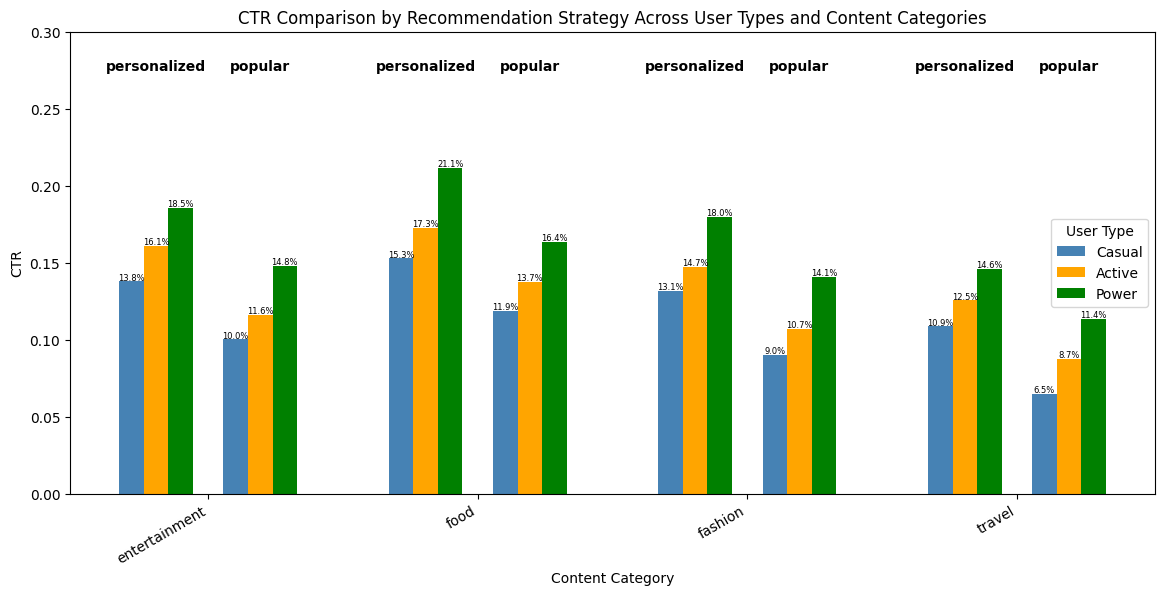

In [85]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
categories=['entertainment','food','fashion','travel']
user_types=['casual','active','power']
colors=['steelblue','orange','green']
bar_width=0.12
recommendation_gap=0.15
category_gap=0.45
x=np.arange(len(categories))*(6*bar_width+recommendation_gap+category_gap)
plt.figure(figsize=(14,6))
for i, user in enumerate(user_types):
    personalized=[ctr_plot.loc[(category,'personalized'),user]
    for category in categories]
    popular=[ctr_plot.loc[(category,'popular'),user]
    for category in categories]
    bars1=plt.bar(x+i*bar_width, personalized, width=bar_width, color=colors[i], label=user)
    for bar in bars1:
        plt.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.001,f'{bar.get_height():.1%}',ha='center',fontsize=6)
    bars2=plt.bar(x+(i+3)*bar_width+recommendation_gap, popular, width=bar_width, color=colors[i])
    for bar in bars2:
        plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,f'{bar.get_height():.1%}',ha='center',fontsize=6)
plt.xticks(x+2.5*bar_width+recommendation_gap/2, categories, rotation=30, ha='right')
plt.title('CTR Comparison by Recommendation Strategy Across User Types and Content Categories')
plt.xlabel('Content Category')
plt.ylabel('CTR')
plt.ylim(0,0.3)
legend_elements=[Patch(facecolor='steelblue',label='Casual'),Patch(facecolor='orange',label='Active'),Patch(facecolor='green',label='Power')]
plt.legend(handles=legend_elements,title='User Type')
for xi in x:
    plt.text(xi+bar_width, 0.275,'personalized',ha='center',fontsize=10, fontweight='bold')
    plt.text(xi+4*bar_width+recommendation_gap,0.275,'popular',ha='center',fontsize=10, fontweight='bold')
plt.show()


### Key Insights

• Personalized recommendations consistently outperformed popularity-based recommendations across all user segments and content categories.

• Power users achieved the highest CTR regardless of recommendation strategy, suggesting that highly engaged users respond well to recommendations overall.

• Casual users exhibited the lowest CTR, but still experienced consistent gains from personalized recommendations.

• The relative improvement from personalization was particularly notable for Travel content, indicating that interest-driven categories benefit more from personalized recommendation.

### Business Recommendation

• Allocate more recommendation resources toward personalized delivery for niche content categories such as Travel.

• Continue leveraging personalized recommendation across all user segments, with particular attention to casual users to improve engagement.

• Use popularity-based recommendation primarily for broad-reach content, while relying on personalization to maximize engagement for specialized interests.

In [86]:
recommendation_log_df.describe()

,event_id,user_id,item_id,popularity_score,quality_score,click_prob,clicked
count,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000
mean,250000.500000,5010.581916,1001.814186,30.667018,51.063794,0.133302,0.132580
std,144337.711635,2887.211583,577.927040,27.740523,29.164048,0.045076,0.339121
min,1.000000,1.000000,1.000000,0.000000,0.000000,0.040000,0.000000
25%,125000.750000,2510.000000,501.000000,6.000000,26.000000,0.101000,0.000000
50%,250000.500000,5019.000000,1002.000000,20.000000,51.000000,0.126400,0.000000
75%,375000.250000,7511.000000,1503.000000,51.000000,77.000000,0.162000,0.000000
max,500000.000000,10000.000000,2000.000000,100.000000,100.000000,0.280000,1.000000


# A/B Testing: Evaluating Recommendation Strategies

## Business Question

Does personalized recommendation significantly improve click-through rate (CTR) compared with popularity-based recommendation?

Should the product team replace the current popularity-based recommendation strategy with personalized recommendation?

## Experiment Design

### Control Group (A)

- Recommendation Strategy: Popular Recommendation

### Treatment Group (B)

- Recommendation Strategy: Personalized Recommendation

### Primary Metric

- Click-Through Rate (CTR)

CTR = Clicks / Impressions

### Unit of Analysis

- Recommendation Impression

Each row in the recommendation log represents one recommendation impression.

In [87]:
ab_summary=recommendation_log_df.groupby('recommendation_type').agg(impression=('clicked','count'),clicks=('clicked','sum'),ctr=('clicked','mean'))
ab_summary


,impression,clicks,ctr
recommendation_type,,,
personalized,299910,44479,0.148308
popular,200090,21811,0.109006


## Formulate Hypotheses

To evaluate whether personalized recommendations outperform popularity-based recommendations, we compare the click-through rate (CTR) between the two recommendation strategies.

### Null Hypothesis (H₀)

There is no difference in CTR between personalized recommendations and popular recommendations.

H₀: CTR_personalized = CTR_popular

### Alternative Hypothesis (H₁)

Personalized recommendations achieve a higher CTR than popular recommendations.

H₁: CTR_personalized > CTR_popular

In [88]:
clicks=ab_summary['clicks']
print(clicks)

recommendation_type
personalized    44479
popular         21811
Name: clicks, dtype: int64


In [89]:
impressions=ab_summary['impression']
print(impressions)

recommendation_type
personalized    299910
popular         200090
Name: impression, dtype: int64


In [90]:
print(clicks)

recommendation_type
personalized    44479
popular         21811
Name: clicks, dtype: int64


In [91]:
from statsmodels.stats.proportion import proportions_ztest

In [92]:
z_state, p_value=proportions_ztest(count=clicks, nobs=impressions,alternative='larger')
print(f'Z_statistic:{z_state:.4f}')
print(f'P_value:{p_value:.6f}')

Z_statistic:40.1497
P_value:0.000000


In [93]:
print(p_value)

0.0


In [94]:
# absolute lift
personalized_ctr=ab_summary.at['personalized','ctr']
popular_ctr=ab_summary['ctr']['popular']
absolute_lift=personalized_ctr-popular_ctr
print(f'Absolute Lift:{absolute_lift:.2%}')

Absolute Lift:3.93%


In [95]:
# relative lift
relative_lift=absolute_lift/popular_ctr
print(f'Relative Lift:{relative_lift:.2%}')

Relative Lift:36.05%


In [96]:
ab_result=pd.DataFrame({'CTR':[popular_ctr,personalized_ctr],'Absolute Lift':[0,absolute_lift],'Relative Ctr':[0,relative_lift]},index=['Popular','Personalized'])
ab_result

,CTR,Absolute Lift,Relative Ctr
Popular,0.109006,0.000000,0.000000
Personalized,0.148308,0.039302,0.360548


##  Experiment Interpretation

### Statistical Interpretation

- The A/B test shows that personalized recommendations achieved a significantly higher click-through rate (CTR) than popularity-based recommendations.

- The p-value is far below the significance level (α = 0.05), indicating that the observed improvement is highly unlikely to be caused by random variation.

- Therefore, we reject the null hypothesis and conclude that personalized recommendations significantly improve user engagement.

### Business Recommendation

Based on the experimental results, personalized recommendation should be adopted as the default recommendation strategy.

The experiment demonstrated both statistical significance and meaningful business improvement in CTR, suggesting that personalized recommendations are more effective at increasing user engagement than popularity-based recommendations.

To maximize business impact, the product team should prioritize personalized recommendations while continuing to optimize recommendation quality for different user segments and content categories.

## Conclusion

This project demonstrates a complete product analytics workflow, including recommendation log simulation, exploratory data analysis, interaction analysis, and A/B testing.

The results suggest that personalized recommendation consistently improves CTR across different user groups and content categories.

The A/B test further confirms that the observed improvement is statistically significant, supporting the adoption of personalized recommendation as the preferred recommendation strategy.

# Limitations and Future Work

## Limitations

Although this project demonstrates a complete product analytics workflow, several limitations should be acknowledged.

### 1. Synthetic Dataset

This analysis is based on a simulated recommendation log rather than production data. While the simulation was designed to resemble a realistic recommendation system by incorporating user preferences, recommendation strategies, and click behavior, it cannot fully capture the complexity of real-world user interactions.

### 2. Simplified User Behavior

User clicks were generated using predefined probability rules. In reality, user engagement is influenced by many additional factors, including browsing history, session context, device type, time of day, interface design, and previous recommendation exposure.

### 3. Limited Business Metrics

This project primarily evaluates recommendation performance using Click-Through Rate (CTR). Although CTR is an important engagement metric, product decisions in real-world recommendation systems are typically based on multiple business metrics, such as:

- Watch Time
- Session Duration
- User Retention
- Conversion Rate
- Revenue per User
- Customer Lifetime Value (LTV)

A recommendation strategy that improves CTR may not necessarily maximize long-term business value.

### 4. Offline Evaluation

The recommendation strategies were evaluated using simulated offline data. In production environments, recommendation systems are continuously validated through online A/B experiments to measure user responses under real-world conditions.

---

# Future Work

Several extensions could further improve this project and better reflect real-world recommendation systems.

### 1. Evaluate Additional Product Metrics

Future analyses could incorporate multiple product metrics beyond CTR, including watch time, session duration, user retention, and conversion rate, providing a more comprehensive evaluation of recommendation quality.

### 2. User Segmentation

Different user groups may respond differently to recommendation strategies. Future work could investigate recommendation performance across:

- New vs. Returning Users
- High-value vs. Low-value Users
- Cold-start Users
- Different demographic groups

This would enable more personalized recommendation strategies.

### 3. Recommendation Ranking Optimization

Rather than comparing only Popular and Personalized recommendations, future work could evaluate multiple ranking algorithms and optimize recommendation order using engagement-based ranking models.

### 4. Predictive Machine Learning Models

Future work could build predictive models to estimate click probability before recommendations are delivered. Candidate models include:

- Logistic Regression
- Random Forest
- XGBoost
- LightGBM

Predicted click probabilities could then be used to optimize recommendation ranking and improve user engagement.

### 5. Online A/B Testing

A natural next step would be deploying the recommendation strategies in an online environment and conducting controlled A/B experiments to validate whether offline improvements translate into real business impact.

---

# Final Takeaway

This project demonstrates an end-to-end product analytics workflow for evaluating recommendation strategies, including synthetic data generation, exploratory data analysis, interaction analysis, visualization, and A/B testing.

The results consistently show that personalized recommendations outperform popularity-based recommendations across different user segments and content categories. Statistical testing further confirms that these improvements are highly significant, supporting the adoption of personalized recommendation as the preferred recommendation strategy.

More importantly, this project illustrates how data-driven experimentation can guide product decisions and optimize recommendation systems to improve user engagement.

# Product Funnel Analysis
## Simulate User Journey

In [160]:
# step 1: Engagement
recommendation_log_df['engage_prob'] = 0.0

#only clicked users can become engaged

recommendation_log_df.loc[recommendation_log_df['clicked']==1,'engage_prob']=0.55

# personalized recommendation increases engagement
recommendation_log_df.loc[recommendation_log_df['recommendation_type']=='personalized', 'engage_prob']+=0.06

# hight-quality items improve engagement

mask= recommendation_log_df['clicked']==1
recommendation_log_df.loc[ mask,'engage_prob']+=(recommendation_log_df.loc[mask, 'quality_score']/100)*0.10

#premium items are more engaging

recommendation_log_df.loc[recommendation_log_df['item_type']=='premium', 'engage_prob']+=0.03
recommendation_log_df['engage_prob']=recommendation_log_df['engage_prob'].clip(0,0.95)
# initialize engaged as 0
recommendation_log_df['engaged']=0
# only clicked users are eligible to become engaged
mask=recommendation_log_df['clicked']==1
recommendation_log_df.loc[mask,'engaged']=(np.random.rand(mask.sum())< recommendation_log_df.loc[mask,'engage_prob']).astype(int)




In [161]:
recommendation_log_df['engaged'].mean()

np.float64(0.08583)

In [164]:
# step 2: Conversion
recommendation_log_df['convert_prob']=0.0
recommendation_log_df.loc[recommendation_log_df['engaged']==1,'conversion']=0.25
recommendation_log_df.loc[recommendation_log_df['item_type']=='premium', 'convert_prob']+=0.04
recommendation_log_df.loc[recommendation_log_df['recommendation_type']=='personalized','convert_prob']+=0.04

In [165]:
# premium items
recommendation_log_df.loc[recommendation_log_df['item_type']=='premium','convert_prob']+=0.03


# Quality score
recommendation_log_df['convert_prob']=(recommendation_log_df['quality_score']/100)*0.06
recommendation_log_df['convert_prob']=recommendation_log_df['convert_prob'].clip(0,0.95)
recommendation_log_df['converted']=(np.random.rand(len(recommendation_log_df))< recommendation_log_df['convert_prob']).astype(int)



In [166]:
# step 3
recommendation_log_df['retain_prob']=0.25
recommendation_log_df.loc[recommendation_log_df['convert']==1,'retain_prob']=0.55
#power user reatain more easily
recommendation_log_df.loc[recommendation_log_df['user_type']=='power','retain_prob']+=0.08
#personalized recommendation
recommendation_log_df.loc[recommendation_log_df['recommendation_type']=='personalized','retain_prob']+=0.04
recommendation_log_df['retain_prob']=recommendation_log_df['retain_prob'].clip(0,0.95)

recommendation_log_df['retained']=0
mask=recommendation_log_df['converted']==1
recommendation_log_df.loc[mask,'retained']=(np.random.rand(mask.sum())< recommendation_log_df.loc[mask,'retain_prob']).astype(int)


In [167]:
recommendation_log_df.head(10)

,event_id,user_id,item_id,recommendation_type,age_group,region,user_type,content_preference,category,item_type,...,preference_match,clicked,engage_prob,engaged,conversion,convert_prob,convert,retain_prob,retained,converted
0,1,186,660,popular,46-55,EU,casual,food,travel,standard,...,False,0,0.000,0,0.00,0.0006,0,0.25,0,0
1,2,2077,1875,popular,18-30,NA,casual,food,travel,standard,...,False,0,0.000,0,0.00,0.0540,0,0.25,0,0
2,3,1432,1763,personalized,31-45,EU,power,food,entertainment,standard,...,False,0,0.060,0,0.00,0.0426,0,0.37,0,0
3,4,747,295,popular,31-45,APAC,casual,fashion,food,trending,...,False,0,0.000,0,0.00,0.0060,0,0.25,0,0
4,5,3835,729,personalized,31-45,NA,casual,food,food,premium,...,True,0,0.090,0,0.00,0.0360,0,0.29,0,0
5,6,8725,30,personalized,55+,NA,casual,entertainment,travel,premium,...,False,0,0.090,0,0.00,0.0438,1,0.59,0,0
6,7,7057,1806,personalized,46-55,EU,casual,travel,entertainment,trending,...,False,0,0.060,0,0.00,0.0120,0,0.29,0,0
7,8,7260,499,personalized,31-45,APAC,casual,food,entertainment,standard,...,False,0,0.060,0,0.00,0.0042,0,0.29,0,0
8,9,2976,704,personalized,18-30,APAC,power,entertainment,entertainment,standard,...,True,1,0.668,1,0.25,0.0348,0,0.37,0,0
9,10,6316,16,popular,55+,EU,power,food,travel,standard,...,False,0,0.000,0,0.00,0.0120,0,0.33,0,0


In [168]:
recommendation_log_df.groupby('retain_prob')['retained'].mean().sort_index()

retain_prob
0.25    0.007565
0.29    0.008715
0.33    0.010700
0.37    0.010535
0.55    0.018357
0.59    0.022773
0.63    0.025578
0.67    0.036949
Name: retained, dtype: float64

In [169]:
## overall funnel
funnel_df=pd.DataFrame({'Stage':['Recommendation Served','Clicked','Engaged','Converted','Retained'],'Users':[len(recommendation_log_df),recommendation_log_df['clicked'].sum(),recommendation_log_df['engaged'].sum(),recommendation_log_df['convert'].sum(),recommendation_log_df['retained'].sum()]})
funnel_df


,Stage,Users
0,Recommendation Served,500000
1,Clicked,66290
2,Engaged,42915
3,Converted,20161
4,Retained,4579


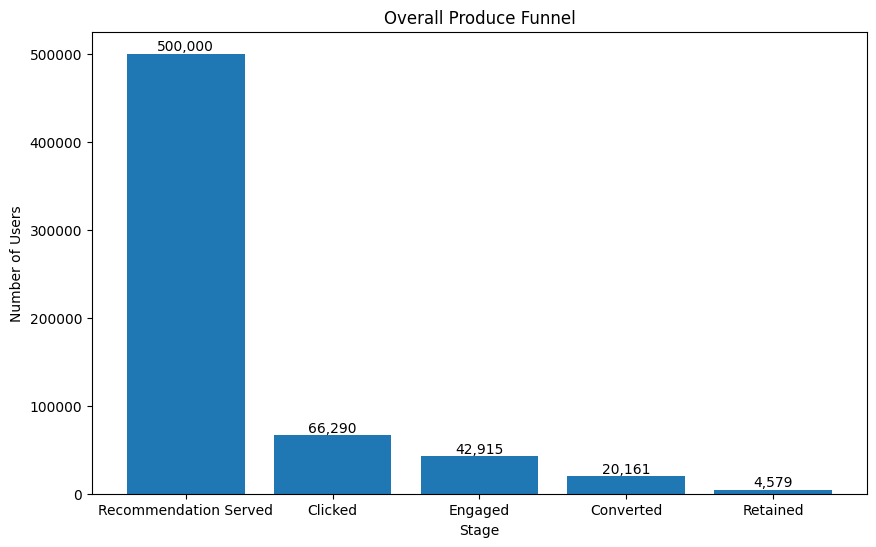

In [170]:
## visualization
plt.figure(figsize=(10,6))
bars=plt.bar(funnel_df['Stage'],funnel_df['Users'])
plt.title('Overall Produce Funnel')
plt.ylabel('Number of Users')
plt.xlabel('Stage')
for bar in bars:
    height= bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, height, f'{height:,}',ha='center', va='bottom')
plt.show()


In [171]:
##compare popular and personalized
funnel_compare=pd.DataFrame()
for rec in ['popular','personalized']:
    temp=recommendation_log_df[recommendation_log_df['recommendation_type']==rec]
    funnel_compare[rec]=[len(temp),temp['clicked'].sum(),temp['engaged'].sum(),temp['convert'].sum(),temp['retained'].sum()]
funnel_compare.index=['Served','Clicked','Engaged','Convert','Retained']
funnel_compare

,popular,personalized
Served,200090,299910
Clicked,21811,44479
Engaged,13299,29616
Convert,8076,12085
Retained,1696,2883


In [185]:

agg_df = recommendation_log_df.groupby('recommendation_type').agg(
    Served=('clicked', 'count'), # 计算总曝光数
    Clicked=('clicked', 'sum'),
    Engaged=('engaged', 'sum'),
    Converted=('converted' if 'converted' in recommendation_log_df.columns else 'convert', 'sum'), # 自动兼容 ed 
    Retained=('retained', 'sum')
).T  

# 2. 建立转化率空表
funnel_compare_rate = pd.DataFrame(index=agg_df.index, columns=agg_df.columns)

# 3. 终极安全计算：使用 .iloc[数字] 代替 .loc['文字'] 
# .iloc 按照第几行来计算，绝对不会因为错别字或大小写而报错
funnel_compare_rate.iloc[0] = 100                                      # 第一行 Served 设为 100
funnel_compare_rate.iloc[1] = (agg_df.iloc[1] / agg_df.iloc[0] * 100).fillna(0) # 第二行 Clicked / 第一行
funnel_compare_rate.iloc[2] = (agg_df.iloc[2] / agg_df.iloc[1] * 100).fillna(0) # 第三行 Engaged / 第二行
funnel_compare_rate.iloc[3] = (agg_df.iloc[3] / agg_df.iloc[2] * 100).fillna(0) # 第四行 Convert / 第三行
funnel_compare_rate.iloc[4] = (agg_df.iloc[4] / agg_df.iloc[3] * 100).fillna(0) # 第五行 Retained / 第四行
funnel_compare_rate=funnel_compare_rate.drop(index='Served')
funnel_compare_rate

recommendation_type,personalized,popular
Clicked,14.830783,10.900595
Engaged,66.584231,60.973821
Converted,30.780659,45.695165
Retained,31.625713,27.908507


In [182]:
# overall journey

overall_journey=pd.DataFrame(index=['Clicked','Engaged','Converted','Retained'])
for rec in ['personalized','popular']:
    temp=recommendation_log_df[recommendation_log_df['recommendation_type']==rec]
    served=len(temp)
    overall_journey[rec]=[temp['clicked'].sum()/served*100, temp['engaged'].sum()/served*100, temp['converted'].sum()/served*100, temp['retained'].sum()/served*100]
overall_journey

,personalized,popular
Clicked,14.830783,10.900595
Engaged,9.874962,6.646509
Converted,3.039579,3.037133
Retained,0.961288,0.847619


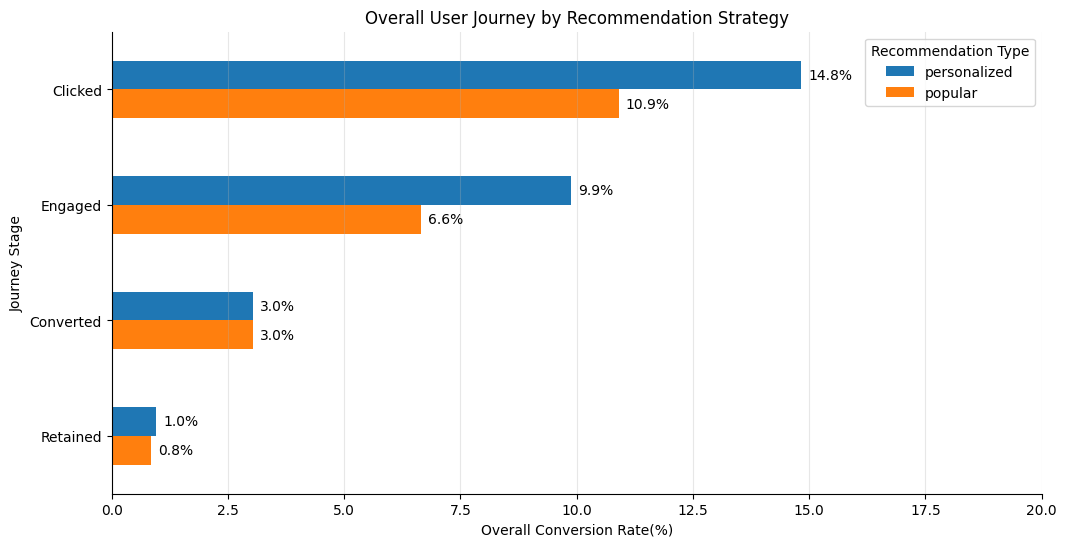

In [189]:
# overall journey visualization

ax=overall_journey.plot(kind='barh',figsize=(12,6))
plt.title('Overall User Journey by Recommendation Strategy')
plt.xlabel('Overall Conversion Rate(%)')
plt.ylabel('Journey Stage')
plt.xlim(0,20)
plt.gca().invert_yaxis()
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(axis='x',alpha=0.3)
for container in ax.containers:
    labels=[f'{v:.1f}%'for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=5)
plt.legend(title='Recommendation Type')
plt.savefig('../figures/overall_user_journey_by_recommendation_strategy.png',dpi=300,bbox_inches='tight')
plt.show()

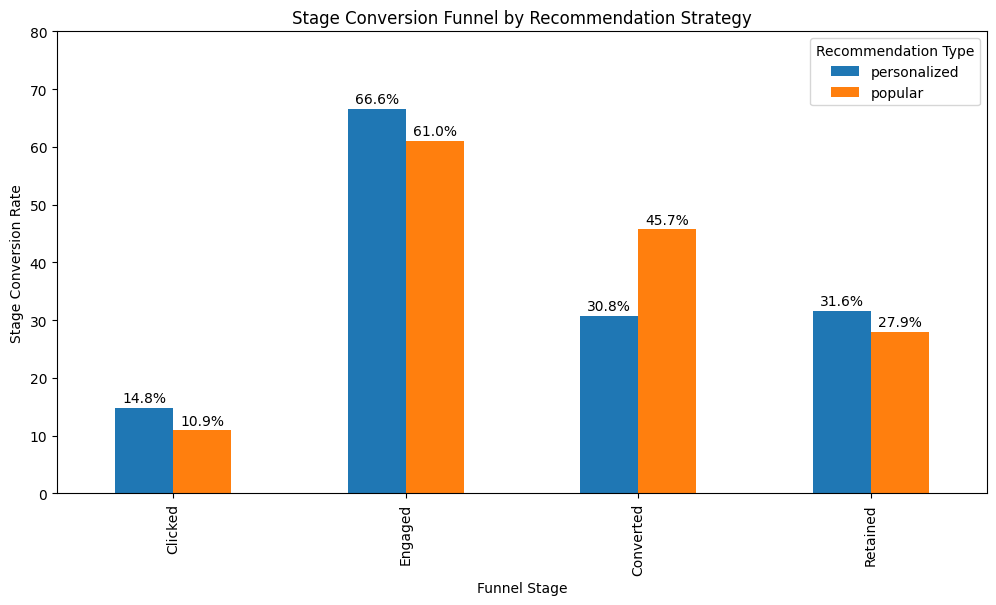

In [191]:
# funnel compare rate
ax=funnel_compare_rate.plot(kind='bar', figsize=(12,6))
plt.title('Stage Conversion Funnel by Recommendation Strategy')
plt.xlabel('Funnel Stage')
plt.ylabel('Stage Conversion Rate')
plt.ylim(0,80)
for container in ax.containers:
    labels=[f'{v:.1f}%' for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=2)
plt.legend(title='Recommendation Type')
plt.savefig('../figures/stage_conversion_funnel_by_recommendation_strategy.png', dpi=300, bbox_inches='tight')
plt.show()


## Business Insight

### Insight 1 — Personalized recommendations consistently outperform popularity-based recommendations.

- Finding

Across the entire user journey, personalized recommendations consistently achieved higher performance than popularity-based recommendations. The advantage was observed not only in click-through rate (CTR), but also in engagement, conversion, and retention.

- Business Impact

This suggests that personalization creates sustained improvements throughout the customer journey rather than simply generating more clicks. Investing in recommendation relevance can therefore improve long-term user value.

### Insight 2 — The largest performance gap appears at the engagement stage.

- Finding

While personalized recommendations improved CTR, an even larger improvement was observed in the engagement stage, indicating that relevant recommendations encouraged users to continue interacting with the platform after the initial click.

- Business Impact

This suggests that recommendation quality influences user engagement beyond the first interaction. Product teams should evaluate recommendation systems using downstream engagement metrics rather than CTR alone.

### Insight 3 — Improvements propagate through the entire conversion funnel.

- Finding

Higher engagement generated by personalized recommendations resulted in higher conversion and retention rates, demonstrating that small improvements at the top of the funnel accumulate into larger business outcomes downstream.

- Business Impact

Optimizing early-stage recommendation quality can create compounding effects across the entire product funnel, ultimately improving user retention and long-term platform performance.

### Insight 4 — Recommendation strategy should be evaluated using multiple product metrics.

- Finding

CTR alone does not fully capture recommendation effectiveness. Funnel analysis showed that recommendation strategies influence multiple stages of the user journey, including engagement, conversion, and retention.

- Business Recommendation

Organizations should adopt a comprehensive evaluation framework combining CTR, engagement, conversion, and retention when measuring recommendation system performance.

## Key Takeaways

- Personalized recommendations consistently outperformed popularity-based recommendations across every stage of the user journey.
- Improvements in recommendation relevance generated compounding gains from click-through to long-term retention.
- Evaluating recommendation systems using multiple downstream metrics provides a more complete assessment than CTR alone.
- Product teams should optimize recommendation strategies for overall user value rather than maximizing clicks alone.

## Limitations and Future Work

- This project uses simulated user behavior based on probabilistic rules to illustrate recommendation strategy evaluation. Future work could validate these findings using real-world behavioral data and more sophisticated recommendation algorithms, such as collaborative filtering or deep learning-based recommenders.